In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use('ggplot')

In [4]:
# Dataset paths
IMAGE_DIR = "dataset/train/images"
LABEL_DIR = "dataset/train/labels"

# Load file lists
images = sorted(os.listdir(IMAGE_DIR))
labels = sorted(os.listdir(LABEL_DIR))

print(f"Working directory: {os.getcwd()}")

Working directory: /home/payals/snow_pole_project


In [6]:
missing_labels = []

for img in images:
    base_name = os.path.splitext(img)[0]
    label_file = base_name + ".txt"
    
    if label_file not in labels:
        missing_labels.append(img)

print("Total images:", len(images))
print("Total labels:", len(labels))
print("Images without labels:", len(missing_labels))

Total images: 322
Total labels: 322
Images without labels: 0


In [7]:
def show_sample():
    img_name = random.choice(images)
    
    img_path = os.path.join(IMAGE_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(img_name)
    plt.show()

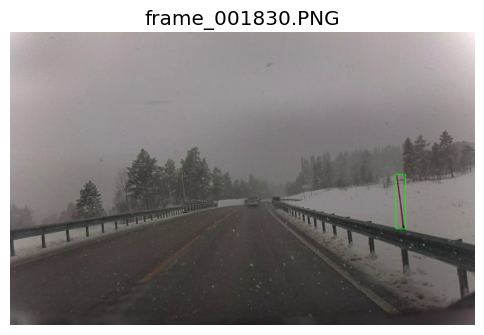

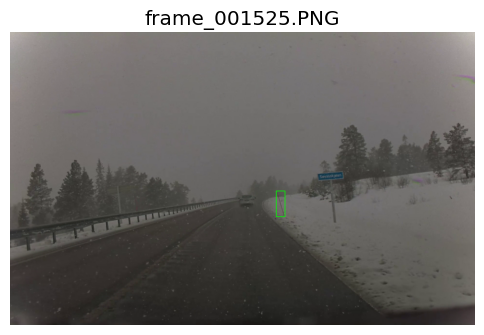

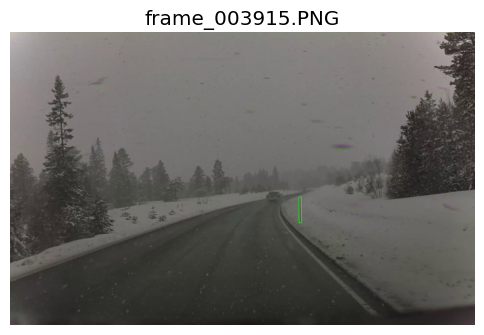

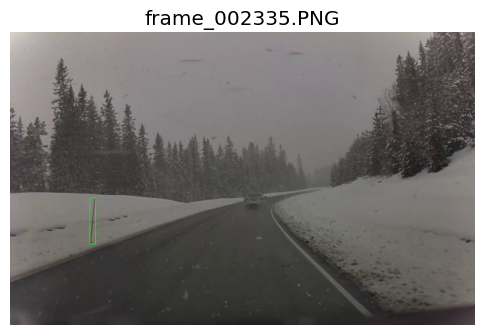

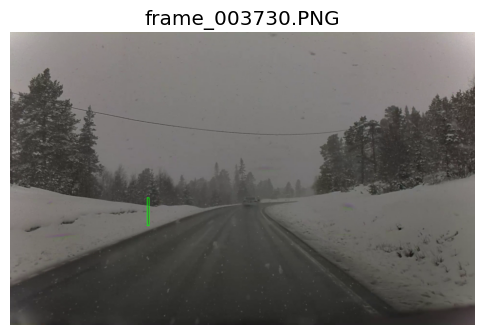

In [8]:
for _ in range(5):
    show_sample()

In [9]:
objects_per_image = []

for file in labels:
    with open(os.path.join(LABEL_DIR, file)) as f:
        count = len(f.readlines())
        objects_per_image.append(count)

# Basic stats
print("Min objects in image:", min(objects_per_image))
print("Max objects in image:", max(objects_per_image))
print("Average objects per image:", np.mean(objects_per_image))

Min objects in image: 1
Max objects in image: 3
Average objects per image: 1.2173913043478262


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(objects_per_image, bins=20, edgecolor='black')
plt.title("Distribution of Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()